# Cls1. MLP from scratch

## Plan

- [x] MLP forward pass in numpy 
- [x] Backprogation for MLP 
- [x] Implement MLP layers
- [ ] Combine into model, implement backpropagation and gradient descent 
- [ ] Train on simple classification

## MLP forward pass 

In [3]:
import numpy as np
rng = np.random.default_rng(seed=42)

In [8]:
p = 10
x = rng.normal(size=(p))

In [10]:
h = 15
weight = rng.normal(size=(p, h))
bias = rng.normal(size=(h))

In [15]:
def sigm(x):
    out = 1 / (1 + np.exp(-x))
    return out

In [16]:
# Linear layer: x @ weight + bias

# input: x

sigm(x @ weight + bias)

array([0.85183073, 0.58817324, 0.88029786, 0.11547654, 0.61533628,
       0.269086  , 0.4235225 , 0.14668453, 0.18484209, 0.99256044,
       0.68269914, 0.81218031, 0.0897011 , 0.0205612 , 0.68599476])

## Backprogataion for MLP

$$\frac{\partial L}{\partial w_{ij}^k} = \left( \frac{\partial L}{\partial y^k} \right)^T \cdot \frac{\partial y^k}{\partial w_{ij}^k}$$

$$\frac{\partial L}{\partial y^{k-1}} = \left( \frac{\partial L}{\partial y^k} \right)^T \cdot \frac{\partial y^k}{\partial y^{k-1}}$$

## MLP Layers

In [24]:
import abc

class Layer(abc.ABC):
    def __init__(self):
        super().__init__()
        self.x_cache = None

    def forward(self, x):
        pass

    def backward(self, grad_upstream):
        pass

    def __call__(self, x):
        return self.forward(x)

In [127]:
class Linear(Layer):
    def __init__(self, n_in, n_out, weight_scale=1):
        super().__init__()
        self.weight = rng.normal(0, weight_scale, size=(n_in, n_out))
        self.bias = np.zeros(n_out)

    def forward(self, x):
        self.x_cache = x

        out = x @ self.weight + self.bias
        return out
    
    def backward(self, grad_upstream):
        x = self.x_cache
        dx = grad_upstream @ self.weight.T
        db = grad_upstream
        dw = x[:, :, None] * grad_upstream[:, None, :]

        return {
            "dx": dx,
            "db": db,
            "dw": dw,
        }


In [128]:
# ReLU(x) = x if x > 0 else 0

class ReLU(Layer):
    def forward(self, x):
        self.x_cache = x
        out = x.copy()
        out[x < 0] = 0

        return out

    def backward(self, grad_upstream):
        x = self.x_cache
        dx = grad_upstream * (x > 0)

        return {
            "dx": dx
        }

In [129]:
class Sigm(Layer):
    def forward(self, x):
        self.x_cache = x

        out = 1 / (1 + np.exp(-x))

        return out

    def backward(self, grad_upstream):
        x = self.x_cache
        dx = grad_upstream / (np.exp(x) + np.exp(-x) + 2) 

        return {
            "dx": dx
        }

In [130]:
import matplotlib.pyplot as plt

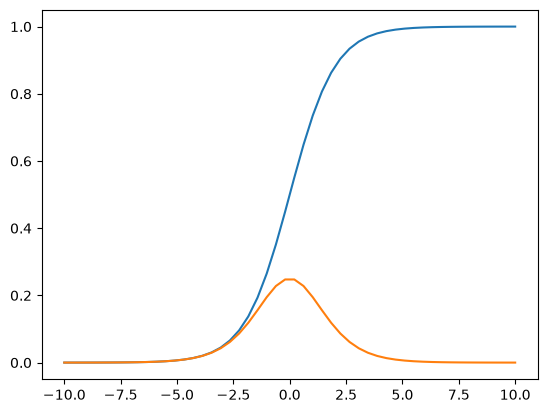

In [131]:
sigm = Sigm()
x = np.linspace(-10, 10, 50)

plt.plot(x, sigm(x))
plt.plot(x, sigm.backward(np.ones_like(x))['dx'])


## MLP & backprop

In [132]:
class MLP(Layer):
    def __init__(self, n_in, n_out, d):
        self.layers = [
            Linear(n_in, d),
            ReLU(),
            Linear(d, d),
            ReLU(),
            Linear(d, d),
            ReLU(),
            Linear(d, n_out),
            Sigm()
        ]

    def forward(self, x):
        out = x
        for l in self.layers:
            out = l(out)

        return out

    def backward(self, grad_upstream, lr=3e-4):

        grad = grad_upstream
        for i in range(len(self.layers)-1, -1, -1):
            grads_layer = self.layers[i].backward(grad)

            if isinstance(self.layers[i], Linear):
                self.layers[i].weight -= lr * grads_layer['dw'].mean(axis=0)
                self.layers[i].bias -= lr * grads_layer['db'].mean(axis=0)

            grad = grads_layer['dx']


In [133]:
mlp = MLP(2, 1, 10)

B = 16
x = rng.normal(0, 1, size=(B, 2))

out = mlp(x)
out

array([[0.99999825],
       [1.        ],
       [0.99998819],
       [0.99978468],
       [1.        ],
       [0.99999707],
       [0.99999419],
       [0.99891094],
       [0.99888492],
       [0.99955711],
       [0.99716146],
       [0.99992913],
       [0.99999999],
       [0.99991863],
       [0.99999589],
       [0.99209145]])

In [134]:
mlp.backward(np.ones_like(out))